# Test the "Momentum" Trading Strategy

This interactive nootebook tests the "momentum" trading strategy and provides some plots for data anlysis.

## Import Packages

In [1]:
from tradelab import *
import matplotlib.pyplot as plt

## Define and Execute Trading Strategy

Define key parameters

In [2]:
tickers = [
    "XLE",  # Energy
    "XLF",  # Financials
    "XLU",  # Utilities
    "XLI",  # Industrials
    "XLK",  # Technology
    "XLV",  # Healthcare
    "XLY",  # Consumer Discretionary
    "XLP",  # Consumer Staples
    "XLB",  # Materials
    "IYR",  # Real Estate
    "IYE",  # Energy (iShares)
    "OIH",  # Oil Services
    "SMH",  # Semiconductors
    "IBB"   # Biotechnology
]

cash = 1000
start_time = "2010-01-01"
end_time = "2026-01-01"

Create data handler, portfolio, strategy and trading engine.

In [3]:
data_handler = YFinanceDataHandler(
    tickers=tickers,
    start_time=start_time,
    end_time=end_time)

position_sizer = PositionSizer()
execution_model = ExecutionModel()

portfolio = Portfolio(deposit=cash)

strategy = Momentum(
    tickers=tickers,
    start_time=start_time,
    end_time=end_time,
    offset="10D",
    rebalance_frequency = 30,
    momentum_lookback = 7,
    volatility_lookback = 7,
    buy_top_n = 1
)

engine = TradingEngine(
    portfolio = portfolio,
    strategy = strategy,
    data_handler = data_handler,
    position_sizer = position_sizer,
    execution_model = execution_model
)

[*********************100%***********************]  14 of 14 completed


For comparison run a buy-and-hold strategies with the MSCI World

In [4]:
msci_data_handler = YFinanceDataHandler(
    tickers=["IWDA.AS"],
    start_time=start_time,
    end_time=end_time)

msci_portfolio = Portfolio(deposit=cash)

msci_strategy = BuyAndHold(
    tickers=["IWDA.AS"],
    start_time=start_time,
    end_time=end_time,
    offset="7D"
)

msci_engine = TradingEngine(
    portfolio = msci_portfolio,
    strategy = msci_strategy,
    data_handler = msci_data_handler,
    position_sizer = position_sizer,
    execution_model = execution_model
)

[*********************100%***********************]  1 of 1 completed

And buy-and-hold strategies for all other ETFs.

In [5]:
etf_data_handlers = [YFinanceDataHandler(
    tickers=[ticker],
    start_time=start_time,
    end_time=end_time,
    progress=False)
    for ticker in tickers]

etf_portfolios = [Portfolio(deposit=cash) for ticker in tickers]

etf_strategies = [BuyAndHold(
    tickers=[ticker],
    start_time=start_time,
    end_time=end_time,
    offset="7D")
    for ticker in tickers]

etf_engines = [TradingEngine(
    portfolio = etf_portfolios[i],
    strategy = etf_strategies[i],
    data_handler = etf_data_handlers[i],
    position_sizer = position_sizer,
    execution_model = execution_model)
    for i in range(len(tickers))]

Run backtests

In [6]:
momentum_history = engine.run_backtest()
msci_history = msci_engine.run_backtest()

Backtesting complete.
Backtesting complete.


In [7]:
etf_histories = [eng.run_backtest() for eng in etf_engines]

Backtesting complete.
Backtesting complete.
Backtesting complete.
Backtesting complete.
Backtesting complete.
Backtesting complete.
Backtesting complete.
Backtesting complete.
Backtesting complete.
Backtesting complete.
Backtesting complete.
Backtesting complete.
Backtesting complete.
Backtesting complete.


## Visualize Performance

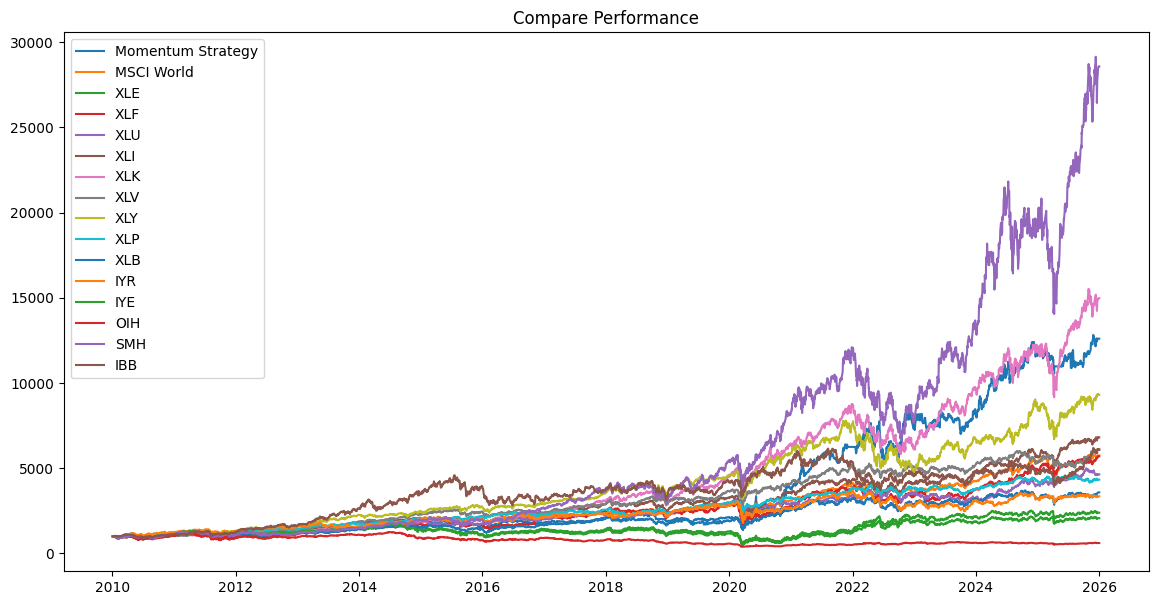

In [8]:
x1, y1 = zip(*((h['timestamp'], h['total_value']) for h in momentum_history))
x2, y2 = zip(*((h['timestamp'], h['total_value']) for h in msci_history))

x_etf = []
y_etf = []

for hist in etf_histories:
    _x, _y = zip(*((h['timestamp'], h['total_value']) for h in hist))
    x_etf.append(list(_x))
    y_etf.append(list(_y))

plt.figure(figsize=(14, 7))
plt.plot(x1,y1, label="Momentum Strategy")
plt.plot(x2,y2, label="MSCI World")

for i in range(len(tickers)):
    plt.plot(x_etf[i],y_etf[i], label=tickers[i])

plt.title("Compare Performance")
plt.legend()
plt.show()

Evaluate Performance

In [9]:
print(f"Total Momentum Strategy Return: {y1[-1]/y1[0]:.2%}")
print(f"Total MSCI World Return: {y2[-1]/y2[0]:.2%}")
print(f"Total number of trades: Momentum: {len(portfolio.trades)}, Buy-And-Hold: {len(msci_portfolio.trades)}")
print(f"Total fees paid: Momentum {portfolio.total_fees_paid:.5}, Buy-And-Hold: {msci_portfolio.total_fees_paid:.3}")

Total Momentum Strategy Return: 1259.97%
Total MSCI World Return: 574.66%
Total number of trades: Momentum: 217, Buy-And-Hold: 2
Total fees paid: Momentum 481.48, Buy-And-Hold: 4.34


Plot the portfolio composition over time

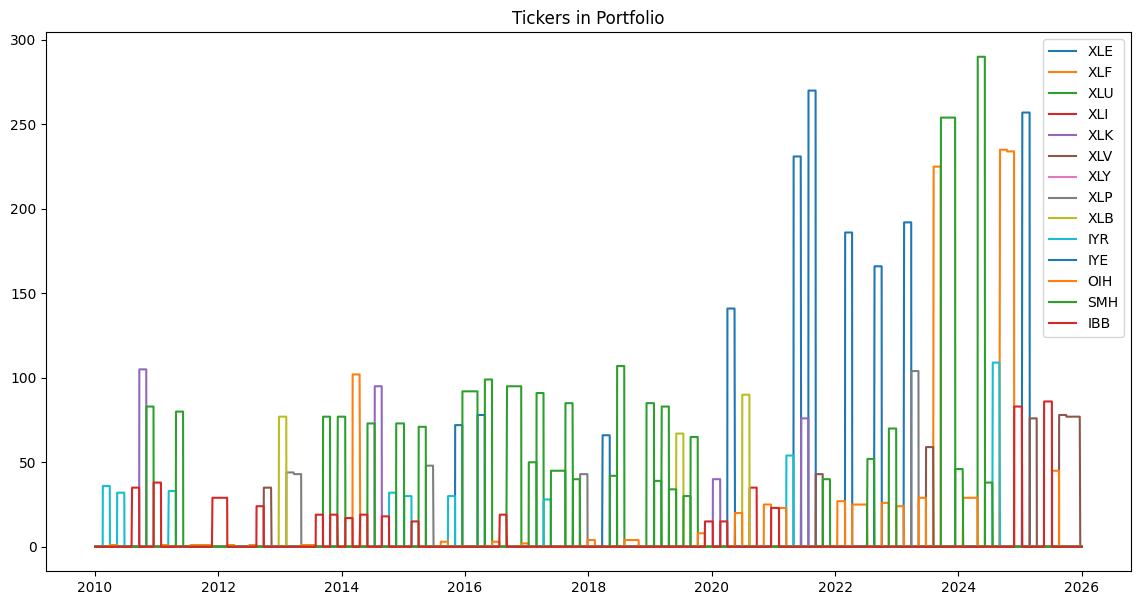

In [10]:
t_vals = [[h.get(ticker, 0) for h in (h['positions'] for h in momentum_history)] for ticker in tickers]
x = [h['timestamp'] for h in momentum_history]

plt.figure(figsize=(14, 7))
for i in range(len(tickers)):
    plt.plot(x,t_vals[i], label=f"{tickers[i]}")
plt.title("Tickers in Portfolio")
plt.legend()
plt.show()

## License

This file is part of TradeLab.

Copyright © 2026 Hannes Malcha

TradeLab is free software: you can redistribute it and/or modify
it under the terms of the GNU General Public License as published by
the Free Software Foundation, either version 3 of the License, or
(at your option) any later version.

TradeLab is distributed in the hope that it will be useful, 
but WITHOUT ANY WARRANTY; without even the implied warranty of 
MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. See the 
GNU General Public License for more details.

You should have received a copy of the GNU General Public License
along with TradeLab. If not, see https://www.gnu.org/licenses/.